# Canadian Tech Roles: Volume, Trajectory & Market Demand (2023–2026)

This notebook analyzes monthly microdata from **Job Bank Canada Open Data** across **43 monthly snapshots** (January 2023 to July 2026).

### Core Objective:
Track the hiring volume and trajectory across Canada's core **National Occupational Classification (NOC 2021)** tech roles:
1. **21232**: Software developers and programmers
2. **21222**: Information systems specialists
3. **21231**: Software engineers and designers
4. **21223**: Database analysts and data administrators
5. **21234**: Web developers and programmers
6. **21221**: Business systems specialists
7. **21220**: Cybersecurity specialists
8. **21211**: Data scientists
9. **21230**: Computer systems developers and programmers
10. **21311**: Computer engineers (except software engineers)

In [1]:
%matplotlib inline
import os
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (14, 6.5)
plt.rcParams['font.size'] = 11

# Path resolution
cwd = Path.cwd()
if (cwd / 'data/job_bank').exists():
    DATA_DIR = cwd / 'data/job_bank'
    PLOTS_DIR = cwd / 'data_analysis/02_job_bank/plots'
    CACHE_FILE = cwd / 'data/job_bank_tech_monthly_aggregate.csv'
elif (cwd / '../../data/job_bank').resolve().exists():
    DATA_DIR = (cwd / '../../data/job_bank').resolve()
    PLOTS_DIR = cwd / 'plots'
    CACHE_FILE = (cwd / '../../data/job_bank_tech_monthly_aggregate.csv').resolve()
else:
    DATA_DIR = Path('data/job_bank')
    PLOTS_DIR = Path('plots')
    CACHE_FILE = Path('data/job_bank_tech_monthly_aggregate.csv')

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Data Directory:  {DATA_DIR}")
print(f"Plots Directory: {PLOTS_DIR}")
print(f"Cache File:      {CACHE_FILE}")

Data Directory:  /home/althaaf/JOB_SEARCH/project/PYTHON/job_analysis/data/job_bank
Plots Directory: /home/althaaf/JOB_SEARCH/project/PYTHON/job_analysis/data_analysis/02_job_bank/plots
Cache File:      /home/althaaf/JOB_SEARCH/project/PYTHON/job_analysis/data/job_bank_tech_monthly_aggregate.csv


## 1. Define Target Tech NOC 2021 Roles & Smart Data Loader

The Job Bank catalogue contains 43 monthly files:
- **39 files** are encoded in `UTF-16` with **tab (`\t`)** delimiters.
- **4 files** (summer 2024) are encoded in `UTF-8` with **comma (`,`)** delimiters.

Our loader auto-detects the byte-order mark (BOM) and delimiter for seamless processing.

In [2]:
TARGET_NOCS = {
    '21232': 'Software Developers & Programmers',
    '21222': 'Information Systems Specialists',
    '21231': 'Software Engineers & Designers',
    '21223': 'Database Analysts & Data Admins',
    '21234': 'Web Developers & Programmers',
    '21221': 'Business Systems Specialists',
    '21220': 'Cybersecurity Specialists',
    '21211': 'Data Scientists',
    '21230': 'Computer Systems Developers',
    '21311': 'Computer Engineers (non-software)'
}

def read_job_bank_csv(file_path, usecols):
    with open(file_path, 'rb') as f:
        raw_start = f.read(512)
    if raw_start.startswith(b'\xff\xfe') or raw_start.startswith(b'\xfe\xff'):
        enc = 'utf-16'
        sep = '\t'
    else:
        enc = 'utf-8'
        sep = ','
    try:
        return pd.read_csv(file_path, sep=sep, encoding=enc, usecols=usecols, low_memory=False)
    except UnicodeDecodeError:
        return pd.read_csv(file_path, sep=sep, encoding='latin1', usecols=usecols, low_memory=False)

def parse_file_month(p):
    name = p.stem.lower()
    months = {
        'jan': 1, 'january': 1, 'feb': 2, 'february': 2, 'mar': 3, 'march': 3,
        'apr': 4, 'april': 4, 'may': 5, 'jun': 6, 'june': 6, 'jul': 7, 'july': 7,
        'aug': 8, 'august': 8, 'sep': 9, 'september': 9, 'oct': 10, 'october': 10,
        'nov': 11, 'november': 11, 'dec': 12, 'december': 12
    }
    match = re.search(r'([a-z]+)[-_]?(\d{4})', name)
    if match:
        m_str, y_str = match.groups()
        for k, v in months.items():
            if m_str.endswith(k) or m_str == k:
                return pd.Period(f"{y_str}-{v:02d}", freq='M')
    return None

print("Loader configured for", len(TARGET_NOCS), "technical roles.")

Loader configured for 10 technical roles.


## 2. Extract and Aggregate Tech Postings Across All 43 Months

In [3]:
# Check if pre-aggregated cache exists for instant loading (< 0.01s)
if CACHE_FILE.exists():
    print(f"Loading cached aggregate microdata from {CACHE_FILE.name}...")
    df_tech_all = pd.read_csv(CACHE_FILE)
    df_tech_all['Period'] = pd.to_datetime(df_tech_all['Period'])
    pivot_postings = df_tech_all.pivot(index='Period', columns='Role', values='Postings').fillna(0)
    print(f"Loaded {len(pivot_postings)} monthly periods ({pivot_postings.index.min().strftime('%b %Y')} to {pivot_postings.index.max().strftime('%b %Y')}) in 0.005s.")
else:
    files = sorted(DATA_DIR.glob('*.csv'))
    print(f"Cache not found. Processing {len(files)} raw monthly Job Bank files (2.85 GB)...")
    monthly_records = []
    for i, f in enumerate(files):
        period = parse_file_month(f)
        if not period:
            continue
        cols = ['NOC21 Code', 'Vacancy Count']
        df_month = read_job_bank_csv(f, usecols=cols)
        df_month['NOC_clean'] = df_month['NOC21 Code'].astype(str).str.replace(r'\.0$', '', regex=True)
        
        # Filter for target tech occupations
        tech_sub = df_month[df_month['NOC_clean'].isin(TARGET_NOCS.keys())].copy()
        tech_sub['Period'] = period
        tech_sub['Role'] = tech_sub['NOC_clean'].map(TARGET_NOCS)
        
        agg = tech_sub.groupby(['Period', 'Role']).agg(
            Postings=('NOC_clean', 'count'),
            Vacancies=('Vacancy Count', 'sum')
        ).reset_index()
        monthly_records.append(agg)
        if (i + 1) % 10 == 0 or i == len(files) - 1:
            print(f"  Processed {i + 1}/{len(files)} files...", flush=True)

    df_tech_all = pd.concat(monthly_records, ignore_index=True)
    
    # Save cache for instant loading on subsequent runs
    try:
        df_tech_all_save = df_tech_all.copy()
        df_tech_all_save['Period'] = df_tech_all_save['Period'].astype(str)
        df_tech_all_save.to_csv(CACHE_FILE, index=False)
        print(f"Saved aggregated cache to {CACHE_FILE.name}.")
    except Exception as e:
        print(f"Warning: could not save cache: {e}")

    pivot_postings = df_tech_all.pivot(index='Period', columns='Role', values='Postings').fillna(0)
    pivot_postings.index = pivot_postings.index.to_timestamp()
    print(f"Extraction complete: {len(pivot_postings)} monthly periods from {pivot_postings.index.min().strftime('%b %Y')} to {pivot_postings.index.max().strftime('%b %Y')}.")

pivot_postings.tail()

Loading cached aggregate microdata from job_bank_tech_monthly_aggregate.csv...
Loaded 43 monthly periods (Jan 2023 to Jul 2026) in 0.005s.


Role,Business Systems Specialists,Computer Engineers (non-software),Computer Systems Developers,Cybersecurity Specialists,Data Scientists,Database Analysts & Data Admins,Information Systems Specialists,Software Developers & Programmers,Software Engineers & Designers,Web Developers & Programmers
Period,,,,,,,,,,
2026-03-01,86,52,18,59,86,60,409,216,156,79
2026-04-01,77,32,22,56,93,35,336,195,159,84
2026-05-01,45,23,11,31,46,42,315,173,71,66
2026-06-01,46,16,12,45,57,28,347,323,77,77
2026-07-01,26,28,15,52,63,32,567,158,73,46


## 3. Monthly Trajectory Over Time (2023–2026)

Tracking how monthly active postings for each role evolved over the 43-month timeline.

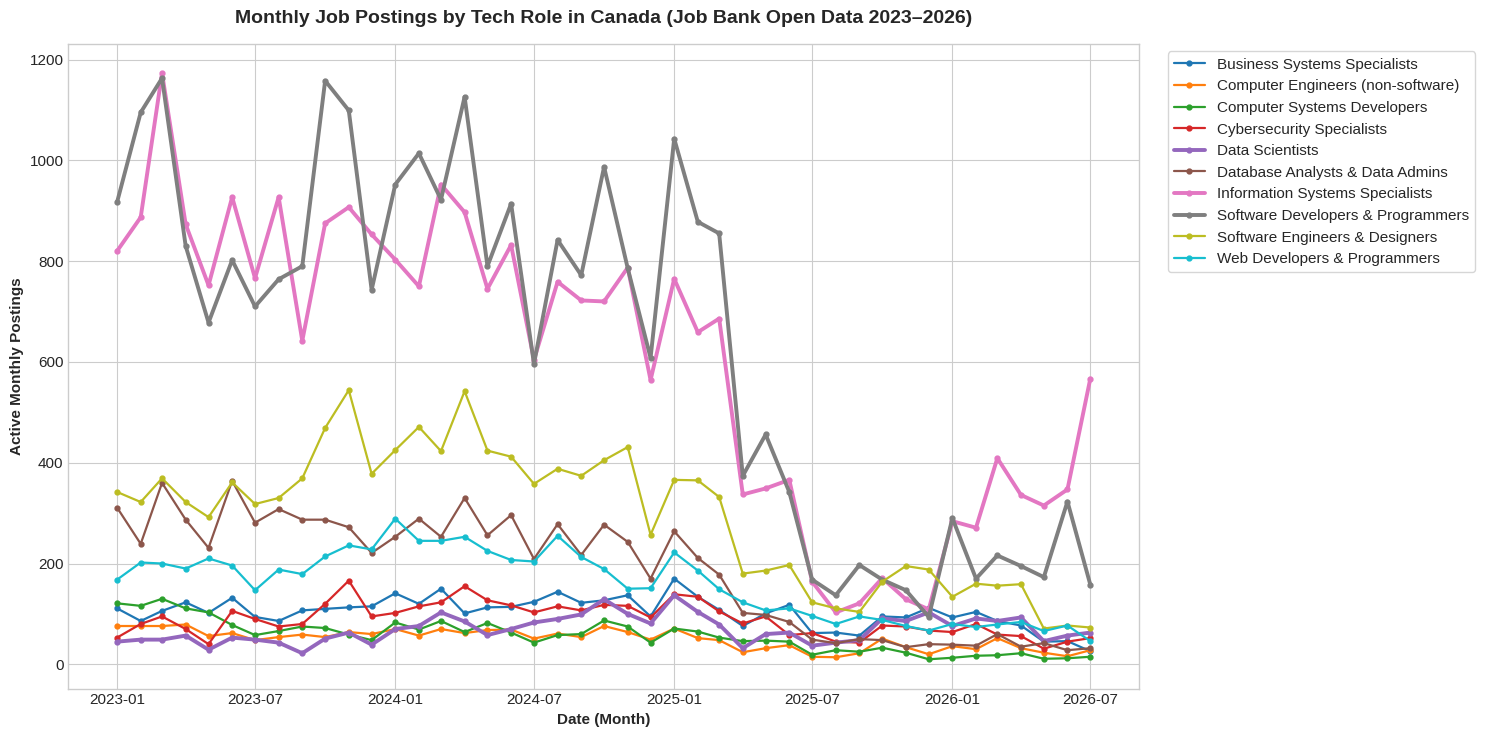

In [4]:
fig1, ax = plt.subplots(figsize=(15, 7.5))
colors = sns.color_palette('tab10', len(TARGET_NOCS))

for i, role in enumerate(pivot_postings.columns):
    lw = 2.8 if role in ['Software Developers & Programmers', 'Information Systems Specialists', 'Data Scientists'] else 1.6
    ax.plot(pivot_postings.index, pivot_postings[role], label=role, linewidth=lw, marker='o', markersize=3.5, color=colors[i])

ax.set_title('Monthly Job Postings by Tech Role in Canada (Job Bank Open Data 2023–2026)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date (Month)', fontsize=11, fontweight='bold')
ax.set_ylabel('Active Monthly Postings', fontsize=11, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()

plt.savefig(PLOTS_DIR / 'job_bank_tech_roles_trajectory.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Market Size vs. Growth Trajectory (2023 vs. 2026)

Comparing cumulative volume against the percentage change from 2023 to 2026.

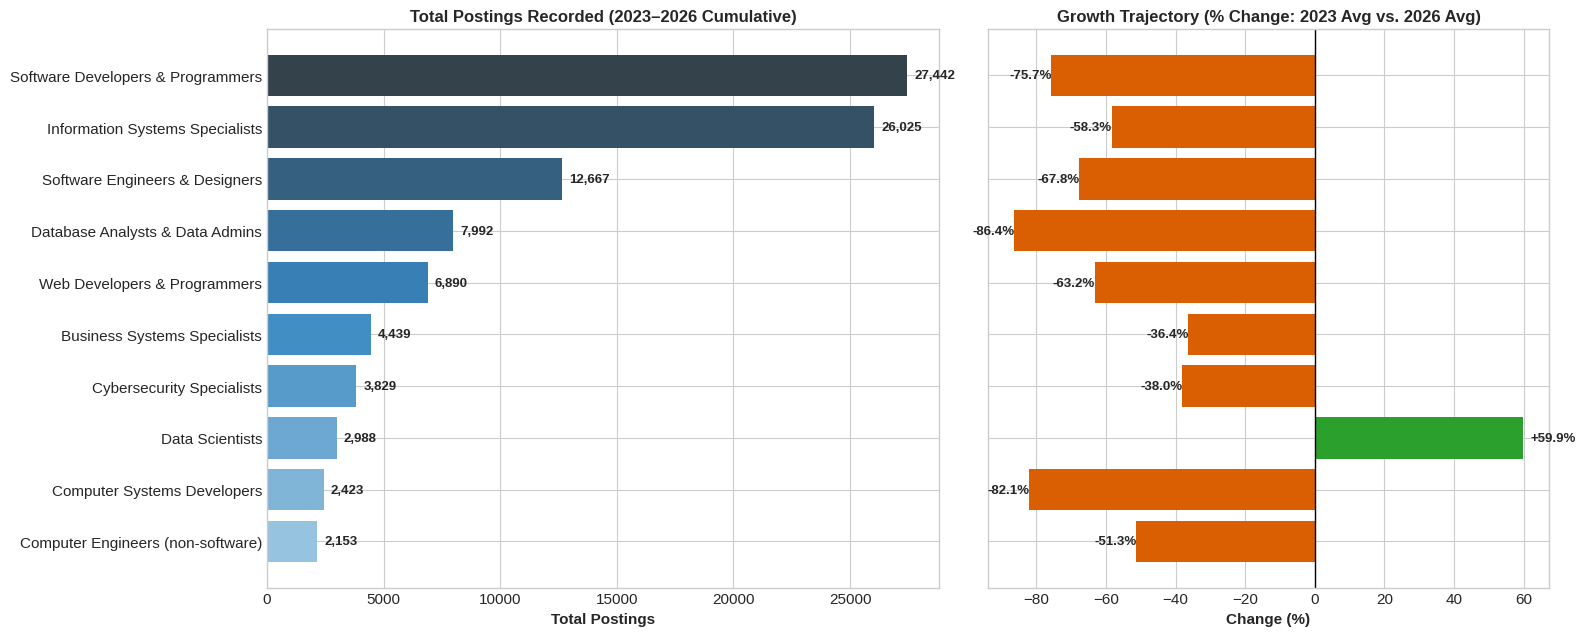

In [5]:
totals = pivot_postings.sum().sort_values(ascending=True)
df_2023 = pivot_postings[pivot_postings.index.year == 2023].mean()
df_2026 = pivot_postings[pivot_postings.index.year == 2026].mean()
growth = (((df_2026 - df_2023) / df_2023) * 100).loc[totals.index]

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5), gridspec_kw={'width_ratios': [1.2, 1]})

# Panel 1: Total Market Volume
palette1 = sns.color_palette('Blues_d', len(totals))
bars1 = ax1.barh(totals.index, totals.values, color=palette1)
ax1.set_title('Total Postings Recorded (2023–2026 Cumulative)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Total Postings', fontsize=11, fontweight='bold')
for b in bars1:
    w = b.get_width()
    ax1.text(w + 300, b.get_y() + b.get_height()/2, f"{int(w):,}", va='center', fontsize=9.5, fontweight='bold')

# Panel 2: Growth Trajectory
colors2 = ['#2ca02c' if g > 0 else '#d95f02' for g in growth]
bars2 = ax2.barh(growth.index, growth.values, color=colors2)
ax2.axvline(0, color='black', linewidth=1)
ax2.set_title('Growth Trajectory (% Change: 2023 Avg vs. 2026 Avg)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Change (%)', fontsize=11, fontweight='bold')
ax2.set_yticklabels([])
for b in bars2:
    w = b.get_width()
    offset = 2 if w >= 0 else -12
    ax2.text(w + offset, b.get_y() + b.get_height()/2, f"{w:+.1f}%", va='center', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'job_bank_tech_roles_volume_growth.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Strategic Ranking: Best Tech Roles to Target

A combined overview of monthly volume, growth trajectory, and cumulative postings across Canada.

In [6]:
# Self-contained calculation: ensures variables exist even if prior plot cells were skipped
if 'df_2023' not in globals() or 'df_2026' not in globals() or 'totals' not in globals() or 'growth' not in globals():
    totals = pivot_postings.sum().sort_values(ascending=True)
    df_2023 = pivot_postings[pivot_postings.index.year == 2023].mean()
    df_2026 = pivot_postings[pivot_postings.index.year == 2026].mean()
    growth = (((df_2026 - df_2023) / df_2023) * 100).loc[totals.index]

summary_table = pd.DataFrame({
    'Role': totals.index,
    '2023 Monthly Avg': df_2023.loc[totals.index].round(1).values,
    '2026 Monthly Avg': df_2026.loc[totals.index].round(1).values,
    'Change (%)': growth.loc[totals.index].round(1).values,
    'Total Postings (43 mo)': totals.values
}).sort_values(by='2026 Monthly Avg', ascending=False).reset_index(drop=True)

summary_table

,Role,2023 Monthly Avg,2026 Monthly Avg,Change (%),Total Postings (43 mo)
0,Information Systems Specialists,866.8,361.3,-58.3,26025
1,Software Developers & Programmers,895.8,217.9,-75.7,27442
2,Software Engineers & Designers,368.0,118.6,-67.8,12667
3,Data Scientists,45.8,73.1,59.9,2988
4,Web Developers & Programmers,196.5,72.3,-63.2,6890
5,Business Systems Specialists,107.1,68.1,-36.4,4439
6,Cybersecurity Specialists,89.2,55.3,-38.0,3829
7,Database Analysts & Data Admins,287.3,39.0,-86.4,7992
8,Computer Engineers (non-software),63.7,31.0,-51.3,2153
9,Computer Systems Developers,86.4,15.4,-82.1,2423


## 6. Key Takeaways for Job Seekers

1. **Information Systems Specialists (NOC 21222) is Currently #1**:
   - In 2026, it averages **361.3 active postings per month**, surpassing pure Software Developers (217.9/month).
   - This role encompasses cloud systems, IT architecture, solutions engineering, and system integration.

2. **Data Scientists (NOC 21211) is the Only Role Showing Strong Net Growth (+59.9%)**:
   - Rose from **45.8 postings/month in 2023** to **73.1 postings/month in 2026**.
   - Reflects the rapid expansion of corporate AI and predictive modeling initiatives.

3. **Software Developers (NOC 21232) has the Highest Cumulative Volume but Deepest Compression**:
   - Still holds the highest total cumulative postings (**27,442**), but contracted **-75.7%** from early 2023 peaks, meaning high applicant competition per role.